In [1]:
import requests
from IPython.core.display import HTML
HTML(f"""
<style>
</style>
""")

# Question 11 a)
K-means and Mean shift

- Clustering: Grouping similar data points together
- K-means: -> K is number of groups
1. Guess where the center of each group might be (This is random!)
2. Assign a fruit group to each center
3. Assign each data point to the group that has the nearest center
4. Change the center to be the average of the assigned points in it’s group
5. Repeat this process (step 3-4) until the groups stop changing
- K-means is evaluated with the WCSS (within-cluster sum of squared distances)

- Mean shift -> Don't choose initial k clusters (Talve)
1. Randomly choose a starting datapoint. Each point has a region of interest.
2. Use Gaussian filter weighting to shift the window region center towards the mean.
3. Keep shifting until it is either stable, or moving very little (or in rings).
4. Do for every point
5. Clusters are the data points that end up at the same center.
- Kmeans more sensitive to outliers, mean shift not
- Kmeans need to decide number of clusters beforehand
- Kmeans can be evaluated using elbow
- Mean shift is algorithmically slow $O(n^2)$

# Clustering
This exercise is about clustering (_K-means clustering_, _Mean-shift clustering_, and _Agglomerative_) pose data used for the exercises in week 2
 and week 10
. The task includes applying and experimenting with each method and then comparing their outcomes. The comparison will be conducted by clustering a sequence of human poses using these three methods in similar steps.
The dataset tensor contains 1403 pose sequences. Each sequence is a 100-frames time series capturing human poses. Each pose consists of 25 skeletal joints, where each joint is defined by an x and y coordinate ($25 \cdot 2$). The shape of the dataset tensor is $(1403, 100, 25 \cdot 2)$. For this exercise, you will use a single pose sequence of 100 frames and apply clustering to the sequence.
## Task overview
For each clustering method you will:
- Implement the method.
- Plot the clusters in the sequence.
- Plot the cluster centers.


<article class="message">
    <div class="message-body">
        <strong>List of individual tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#loading00">Task 1: Introduction</a>
            </li>
            <li>
            <a href="#loading_files">Task 2: Setting up the data</a>
            </li>
            <li>
            <a href="#loading">Task 3: Fitting the algorithm</a>
            </li>
            <li>
            <a href="#loading2">Task 4: K-means clustering visualization</a>
            </li>
            <li>
            <a href="#loading02">Task 5: Cluster characteristics 1</a>
            </li>
            <li>
            <a href="#loading022">Task 6: Cluster centers</a>
            </li>
            <li>
            <a href="#loading023">Task 7: Cluster centers</a>
            </li>
            <li>
            <a href="#loading3">Task 8: Elbow Method</a>
            </li>
            <li>
            <a href="#loading4">Task 9: Fitting the mean-shift algorithm</a>
            </li>
            <li>
            <a href="#loading5">Task 10: Visualizing clusters</a>
            </li>
            <li>
            <a href="#loading9">Task 11: Reflection and the bandwith parameter</a>
            </li>
            <li>
            <a href="#loading10">Task 12: Dendrograms</a>
            </li>
            <li>
            <a href="#loading123">Task 13: Dendogram</a>
            </li>
            <li>
            <a href="#loading11">Task 14: Fitting the agglomerative clustering alg…</a>
            </li>
            <li>
            <a href="#loading12">Task 15: Agglomerative clustreing algorithm mean …</a>
            </li>
            <li>
            <a href="#loading122">Task 16: Agglomerative clustreing algorithm mean …</a>
            </li>
            <li>
            <a href="#loading13">Task 17: Compare and reflect on the methods</a>
            </li>
        </ul>
    </div>
</article>


---
**Task 1 (easy): Introduction💡**
1. Which information can be obtained by clustering a sequence of pose data. Include distance metrics and window size in your discussion.
2. Identify possible pitfalls.


---

## Answer:
We get some information on the movement of the joints, fx if one joint is not moving a lot through the sequence of frames, then there will be a lot of data points in the same cluster. But if a joint moves a lot, the data points' coordinates will be more spread out. 

The following cells import libraries and provide functions for plotting the poses:


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
from sklearn.cluster import MeanShift
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.spatial.distance import pdist, squareform
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage
from clustering_utils import *


# Suppress the specific warning
warnings.filterwarnings("ignore")


---
**Task 2 (easy): Setting up the data👩‍💻**
1. Run the cell below to load and reshape the dataset.
2. Choose the 100th pose sequence as the dataset.


---

In [3]:
data = np.load('poses_norm.npy')
N,T,D,C = data.shape
reshaped_data = data.reshape(N,T,D*C)
sequence = reshaped_data[100] # Albert said to change this to 100 so that results matches the website
print(sequence.shape)

(100, 50)


## K-means Clustering
In this  exercise you will use k-means clustering on a pose sequence. 

---
**Task 3 (easy): Fitting the algorithm👩‍💻**
1. Run the cell below to create an instance of the `KMeans`
 class with 7 clusters and to find clusters in the sequence.


---

In [17]:
# Specify the number of clusters (k)
k = 7

# Create KMeans 
kmeans = KMeans(n_clusters=k, random_state=42)

# Fit to the data
kmeans.fit(sequence)

,n_clusters,7
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'



---
**Task 4 (easy): K-means clustering visualization👩‍💻**
1. Use the [documentation on the `labels_`
 attribute.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
 to obtain cluster labels. 
2. Use the `plot_single_pose`
 function from the file `clustering _utils.py`
 to color each pose in the pose sequence according to which cluster it belongs to. 


---

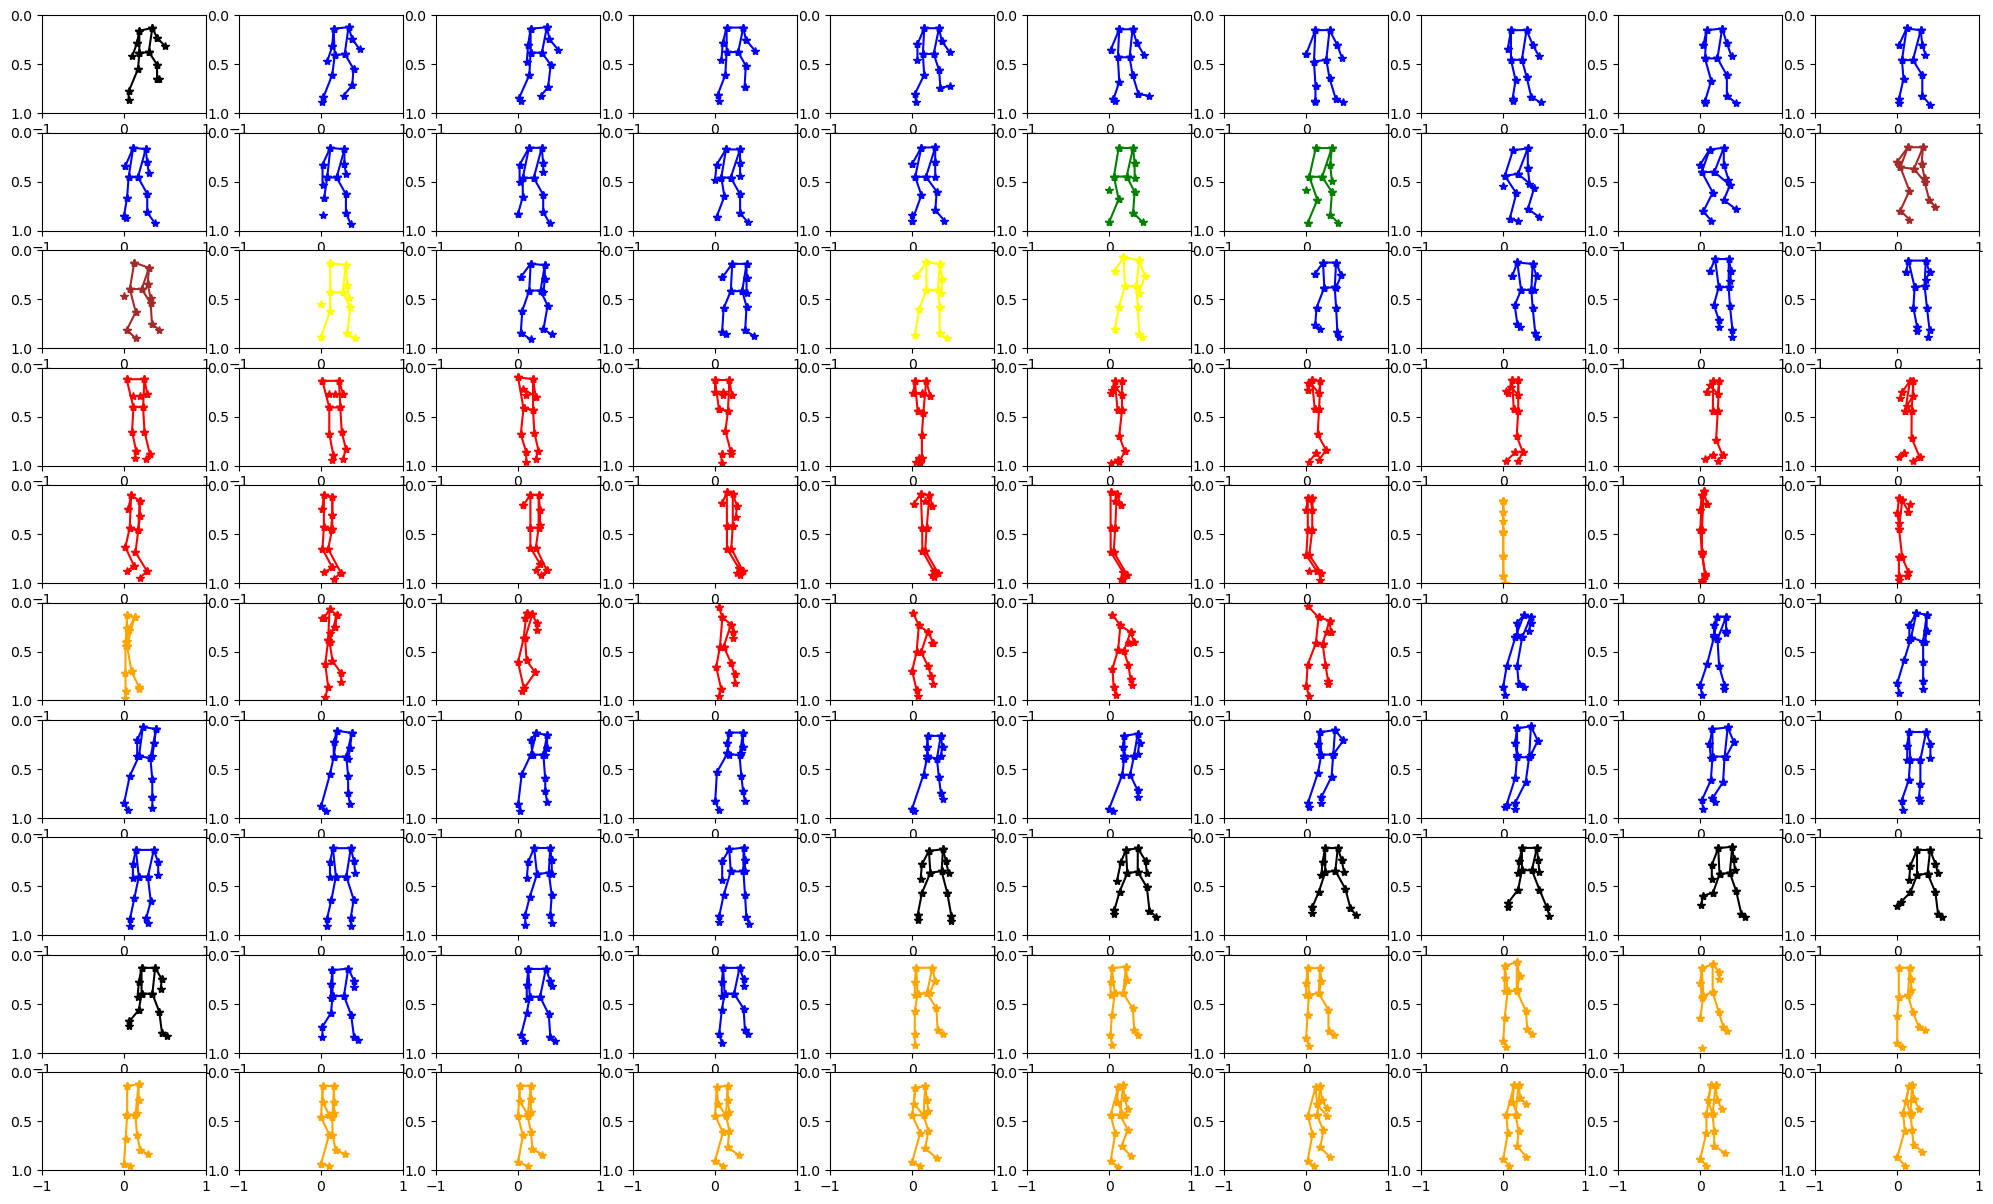

In [18]:
# Write your solution here

# You can now use 'cluster_labels' to see which cluster each frame belongs to
# 'centroids' contains the coordinates of the cluster centers
cluster_labels = kmeans.labels_
centroids = kmeans.cluster_centers_

#colors = {0: 'red', 1: 'blue', 2: 'green', 3: "orange", 4: "black", 5: "brown", 6: "yellow", 7: "cyan"}  # Map cluster labels to colors
colors = {
    0: 'red', 1: 'blue', 2: 'green', 3: 'orange', 4: 'black', 5: 'brown', 6: 'yellow', 7: 'cyan', 8: 'magenta', 9: 'lime', 10: 'teal', 11: 'indigo', 
    12: 'violet', 13: 'gold', 
    14: 'silver', 15: 'pink', 16: 'maroon', 17: 'navy', 18: 'olive', 19: 'purple', 20: 'gray', 21: 'beige', 22: 'coral', 23: 'khaki', 24: 'lavender', 
    25: 'salmon', 26: 'skyblue', 27: 'turquoise', 28: 'white', 29: 'fuchsia'
}

plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)


---
**Task 5 (easy): Cluster characteristics 1💡**
1. What characterizes the _blue_, _green_ and _red_ poses?


---

## Answer:
Red: These poses are more turned to the side, and the arms seem to be higher up. It looks like the poses that the badminton player makes when hitting the ball. 

Blue: In these poses, the player is only turned slightly to the side but is mostly facing forward with the arms along the sides. It looks like the player is in defense (or just in waiting position) because their arms are not raised up high.

Green: Shows almost the same as blue, can't really see the difference. Albert says that it is maybe a bit hard to tell the difference because 7 clusters might not be the optimal amount for this dataset.


---
**Task 6 (easy): Cluster centers👩‍💻**
1. Run the cell below to extract and plot the cluster centers.


---

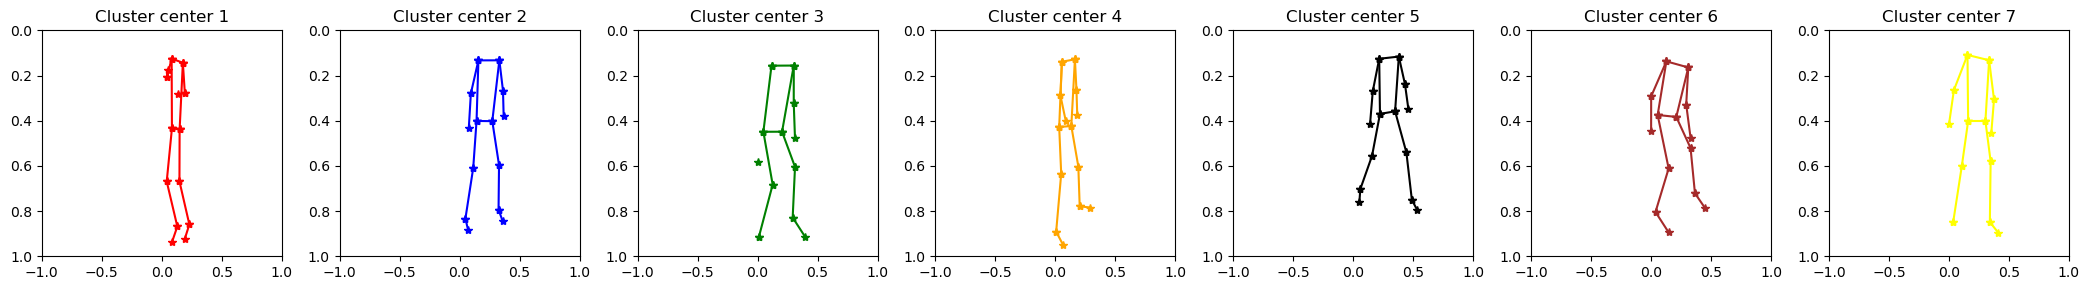

In [19]:
num_centroids = len(centroids)
# Set up subplots
fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))

# Assuming you have a function plot_single_pose defined
for i in range(len(centroids)):
    plt.subplot(1, len(centroids), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(centroids[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()


---
**Task 7 (easy): Cluster centers👩‍💻💡📽️**
1. Visually inspect the results and identify the characteristics of the poses in each cluster: 
    - What distinguishes the clusters?
    - What do the cluster centers represent?
    - What do the clusters reveal about poses?
    - How do the cluster centers relate to your observations in [Task 5](#loading02)?


2. Reason about the choice of 7 clusters and the effect on the result.

3. Change the random state and fit the model again. Explain whether you obtain different groupings and why? 



---

## Answer:
1. Red: "Attack" position, turned to the side and arms close to or above the head. 

    Blue, green, black, brown, and yellow: More "passive" or waiting position, or playing defense where the player doesn't turn much from side to side but mostly uses their arms in a lowered position. Slight bend in the knees. Black poses seem to be further away from the camera 

    Orange: Player is about to turn to the side, ready to hit the ball, looks to be more in an "attacking" position. 

    The cluster centers represent the pose that is in the middle of each cluster. Each centroid being located at the centre of each cluster. The centroid doesn't necessarily have to coincide with an existing data point. 

    The clusters reveal that the poses differ in several ways, and that they can be grouped together with the poses that they are most similar to in regards to the position of the joints. 
2. Using 7 clusters is an arbitrary number right now, and it seems like it might not be the most optimal amount of clusters, because we see fx the green cluster which consists of only 2 poses, and these two poses look quite similar to the blue cluster. So it looks like maybe we should use less clusters so that the clusters become larger. Or we should maybe make even more clusters, so that the poses can be grouped together in a more detailed (fine-grained) way, where it might be clearer what the differences between the clusters are.  

3. Changing the random states gives us different groupings. The random state in kMeans is used when the first random centroids are initialized. By default, the centroids are chosen at random so each time we run the algorithm, the results will be different. Giving a random state to the algorithm makes it possible for us to reproduce the same results.  
https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
Best cluster centers are those that minimize Sum of Squared Distance between all points and their nearest cluster center. Use WCSS for this. 

This task is about using the Elbow Method to choose the number of clusters `k`
.

---
**Task 8 (medium): Elbow Method👩‍💻💡📽️**
The cell below:
- Applies k-means clustering to the sequence using each `k`
 in the interval `k_range`
.
- Extracts the within-cluster sum of squares (WCSS) using [`kmeans.intertia_`
](https://scikit-learn.org/1.5/modules/generated/sklearn.cluster.KMeans.html)
 and store it in a list.
- Plots the within-cluster sum of squares as a function of the number of clusters (elbow curve as displayed below) 

1. Explain the reasons for using WCSS to choose the number of clusters. 

2. What charaterizes the optimal WCSS for choosing the number of clusters?

3. Visually determine the optimal number of clusters.

4. Calculate the rate of change for the elbow curve and plot its absolute value. Use the curve to determine the optimal `k`
.

5. Revisit and run the previous tasks ([Task 3](#loading), [Task 4](#loading2) and [Task 5](#loading02) ) with the optimal number of clusters. 

6. How does the elbow method influence the results in the previous tasks?



---

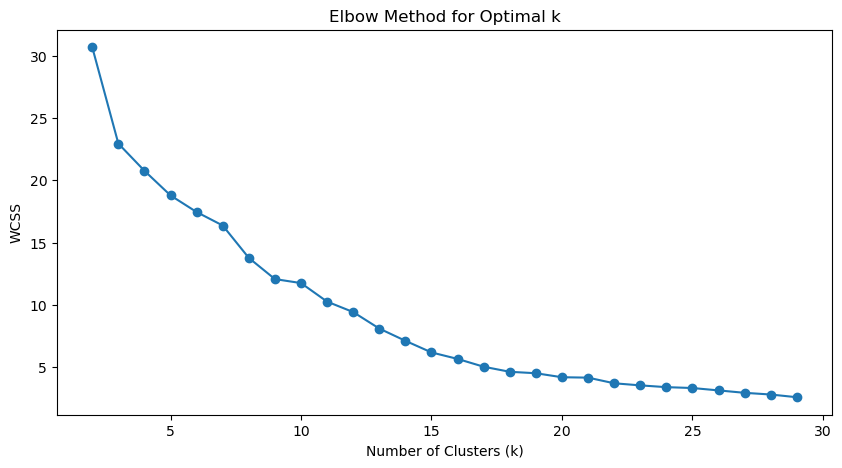

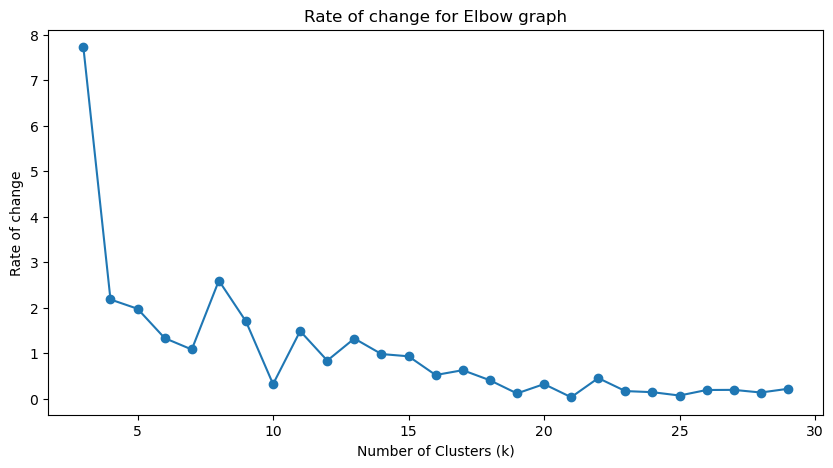

In [7]:
# Find the optimal k using the elbow method
k_range = range(2, 30) # values for the number of clusters `k`
inertia = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(sequence)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(k_range[1:], np.abs(np.diff(inertia)), marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Rate of change')
plt.title('Rate of change for Elbow graph')
plt.show()

## Answers:
1. Explain the reasons for using WCSS to choose the number of clusters. 

    WCSS (also called inertia) is used to calculate the sum of squared distances between each data point and the centroid of its assigned cluster. So you take one centroid and then calculate the distance from each point in that cluster to the centroid and then square it, and then you do the same for each centroid and then you add them all together. A lower value suggests better clustering.  

2. What charaterizes the optimal WCSS for choosing the number of clusters?

    The optimal WCSS is when we see "the elbow drop". Pick the K where within-cluster sum of squares starts to flatten or falls suddenly (differential). 

3. Visually determine the optimal number of clusters.
    
    Seems like around 15-20 could be the optimal number, because that's when it starts to flatten, but it's hard to tell. 

    We also think it could be aroun 8 clusters that is the most optimal, as that is also where th graph starts to flatten a bit. 

4. Calculate the rate of change for the elbow curve and plot its absolute value. Use the curve to determine the optimal `k`.

    Done. Optimal value seems to be around 15-20, as that is where the rate of change gets smaller. 

    Could also again be around 8, it's hard to know for sure because the elbow method is not very precise (in this case at least).

5. Revisit and run the previous tasks ([Task 3](#loading), [Task 4](#loading2) and [Task 5](#loading02) ) with the optimal number of clusters. 

6. How does the elbow method influence the results in the previous tasks?

    We get more clusters, and the poses within each cluster don't vary as much as before. So the clustering seems to be more precise and detailed, instead of making these big clusters with many poses that look quite different to each other. It is also easier to distinguish/differentiate between the different centroids. When we had fewer clusters, some of the centroids looked a lot like each other, whereas with more clusters it is easier to see the small changes in joint positions that differentiate the clusters. 

## Mean-shift Clustering
This exercise is about applying mean-shift clustering to the sequence of poses. 

---
**Task 9 (easy): Fitting the mean-shift algorithm👩‍💻**
1. Run the cell below to:    
    - create an instance of the `MeanShift()`
 class with a bandwith of 0.629 
    - cluster the pose sequence.




---

In [36]:
# Perform Mean Shift clustering
mean_shift = MeanShift(bandwidth=0.629)
mean_shift.fit(sequence)

,bandwidth,0.629
,seeds,None
,bin_seeding,False
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300



---
**Task 10 (easy): Visualizing clusters👩‍💻**
1. Extract the cluster labels for each pose in the sequence. Use the `labels_`
 attribute as described in the [documentation on mean-shift clustering.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html)

2. Visualize the pose sequence, assigning a distinct color to each pose based on its cluster.
3. Extract and plot the cluster centers using the `cluster_centers_`
 attribute.


---

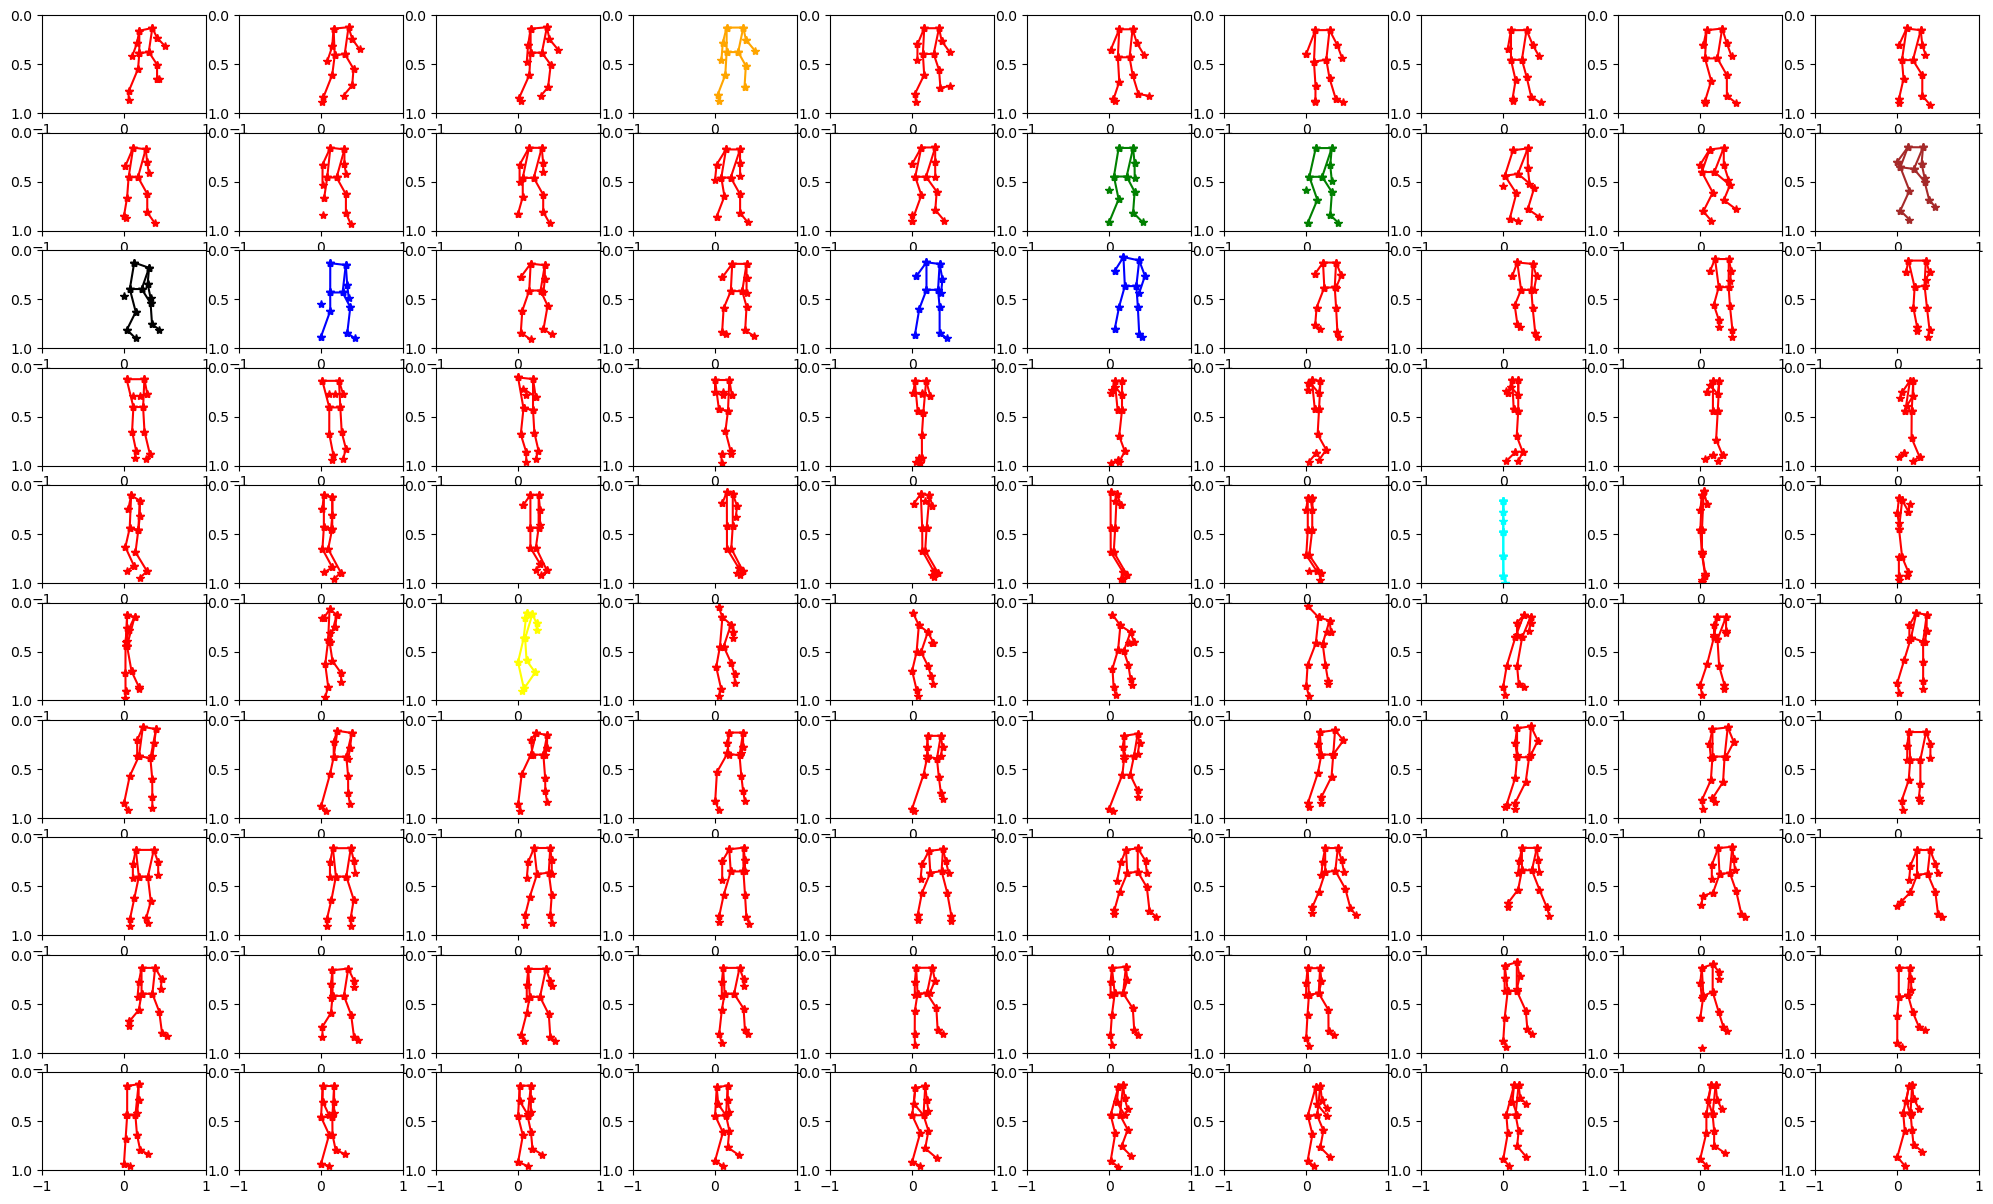

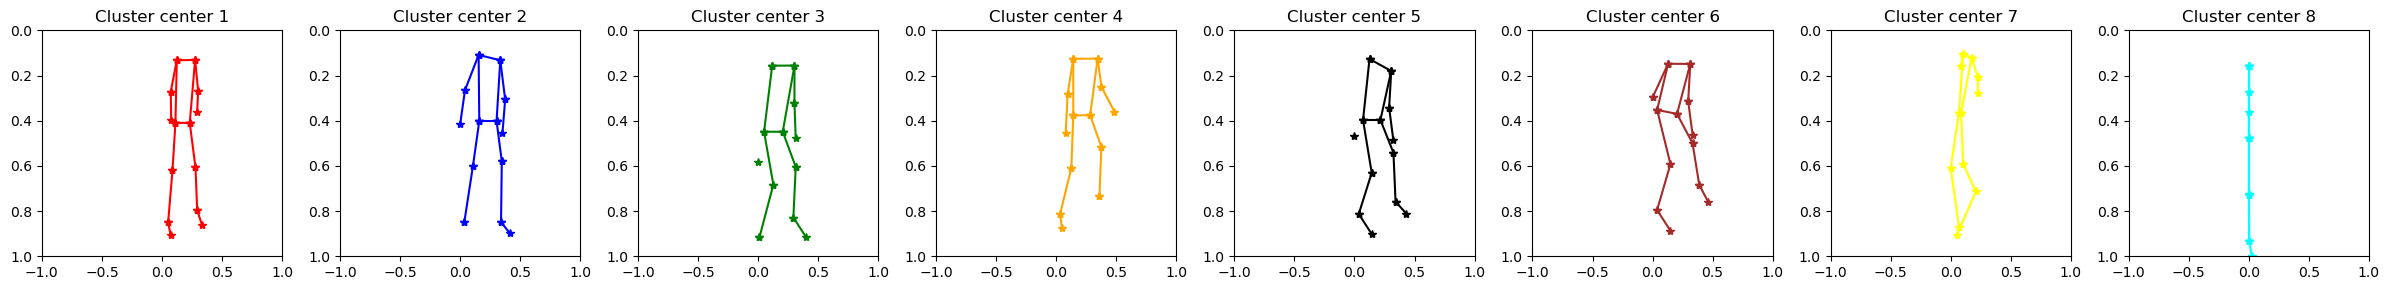

In [37]:
# Write your solution here
cluster_labels_mean_shift = mean_shift.labels_
centroids_mean_shift = mean_shift.cluster_centers_

colors = {
    0: 'red', 1: 'blue', 2: 'green', 3: 'orange', 4: 'black', 5: 'brown', 6: 'yellow', 7: 'cyan', 8: 'magenta', 
    9: 'lime', 10: 'teal', 11: 'indigo', 12: 'violet', 13: 'gold',  14: 'silver', 15: 'pink', 16: 'maroon', 
    17: 'navy', 18: 'olive', 19: 'purple', 20: 'gray', 21: 'beige', 22: 'coral', 23: 'khaki', 24: 'lavender', 
    25: 'salmon', 26: 'skyblue', 27: 'turquoise', 28: 'white', 29: 'fuchsia', 30: 'mustard', 31: 'lilac', 32: 'tan'
}

plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels_mean_shift[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

num_centroids = len(centroids_mean_shift)
# Set up subplots
fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))

# Assuming you have a function plot_single_pose defined
for i in range(len(centroids_mean_shift)):
    plt.subplot(1, len(centroids_mean_shift), i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(centroids_mean_shift[i], c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

plt.tight_layout()
plt.show()



---
**Task 11 (easy): Reflection and the bandwith parameter👩‍💻💡**
1. Visually examine the plots. What are the characteristics of the poses belonging to each cluster?
2. What is the purpose and what effect of decreasing and increasing the bandwidth parameter to 0.429 and 0.829 have and why?


**Info**
You might encounter longer run times for lower bandwith values.


---

## Answers: 
1. Red cluster seems to capture A LOT of the poses, so it is hard to say any characteristics. It is both when the player is facing the net/camera and also when the player is turned to the side, and also both with the hands below and above the head. The other clusters are very small with only 1 or 2 poses in each cluster, so it also doesn't really make sense to talk about characteristics here. 

2. 0.429 creates more clusters (12 clusters), while 0.829 creates 8 clusters. The original bandwidth of 0.629 also creates 8 clusters. Bandwidth is also called window size, and it defines the size of the search window. The algorithm starts by selecting a data point at random and defines a window or a kernel around it. The algorithm uses the window to examine a smaller part/section of the data, and the window then shifts towards the densest part of the data. Within the window, the mean/average of the data points is calculated, and the center of the window is then shifted towards this mean. A smaller window might lead to finer-grained results, while larger window might merge multiple clusters into one.

Mean-shift does not require specifying the number of clusters in advance. The number of clusters is determined by the algorithm with respect to the data.

## Agglomerative Clustering
This exercise is about applying hierarchical clustering to the poses dataset.

---
**Task 12 (easy): Dendrograms👩‍💻**
1. Run the cell below to generate a dendrogram. 


---

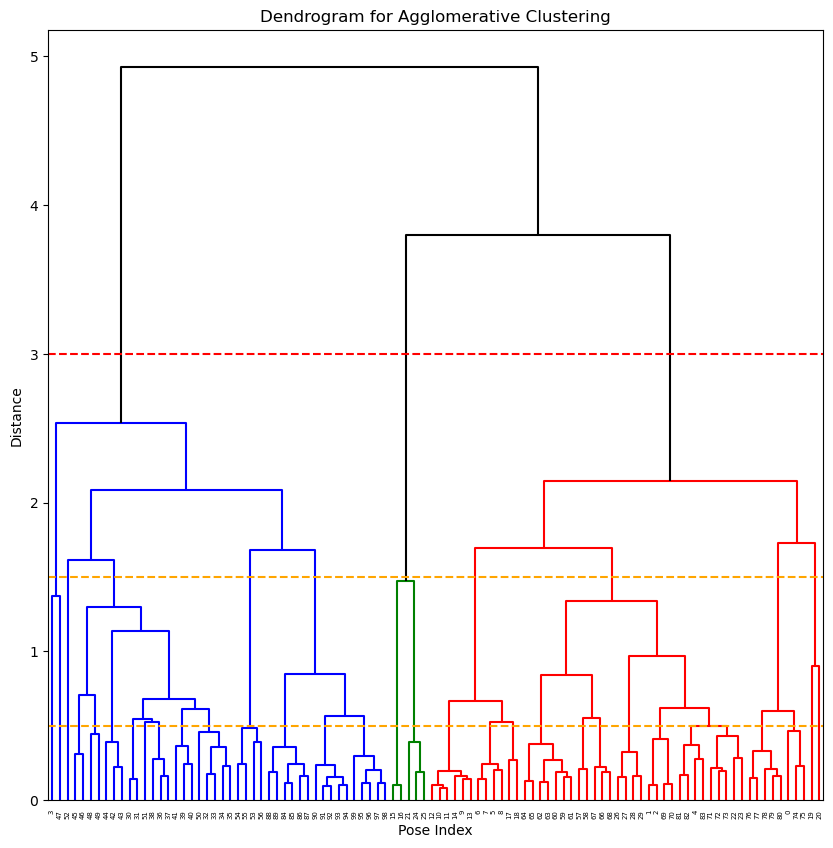

In [10]:
colors = {0: 'black', 1: 'blue', 2: 'green', 3: 'red'}
sns.set_palette([colors[i] for i in range(len(colors))])
shc.set_link_color_palette(None)
plt.figure(figsize=(10,10))
plt.title('Dendrogram for Agglomerative Clustering')
plt.xlabel('Pose Index')
plt.ylabel('Distance')
linkage_matrix = shc.linkage(sequence, method ='ward', metric="euclidean")
Dendrogram = shc.dendrogram(linkage_matrix)
plt.axhline(y = 3, color = 'r', linestyle = '--')
plt.axhline(y = 0.5, color = 'orange', linestyle = '--')
plt.axhline(y = 1.5, color = 'orange', linestyle = '--')


---
**Task 13 (easy): Dendogram💡📽️**
1. How can the number of clusters be determined from the dendrogram?
2. What does the location of a merge node in the dendrogram represent? If two points merge at a very low height, what does it tell about them?
3. Explain what a large differences in node location in the dendogram imply.
4. How many clusters would result from setting the distance threshold to: 0.5, 1.5, 3.0, 4?
5. What types of relationships can agglomerative clustering reveal that non-hierarchical methods might miss?


---

## Answers: 
1. Determine the largest vertical distance that doesn’t intersect any of the other clusters. Draw horizontal line through here. Check how many vertical lines it intersects. In this case I think it is 3, I have added a red line here. 
2. The height of the dendrogram shows the distance between the clusters. The longer the vertical line, the further apart the clusters are. The horizontal lines show the merging of clusters. The height at which the horizontal line is cut by the vertical line indicates the distance at which the clusters were merged. If two points merge at very low height, it means they are close to each other. 
3. I don't really understand this question. I guess it means that the distance between the clusters is very large? 
4. I think I need to look at y-axis here. Distance 0.5: around 30 clusters? Distance 1.5: 10 clusters. Distance 3.0: 3 clusters. 4: 2 clusters. 
5. Agglomerative clustering gives more insight into relationships (hierarchical) within the data. It is more flexible, as it does not require the number of clusters to be predefined. "Firstly, it can handle non-spherical and differently sized clusters. Secondly, it does not require the user to specify the number of clusters beforehand. Thirdly, it provides a hierarchy of clusters, which can be useful for further analysis. However, one of the disadvantages of Agglomerative Clustering is its computational complexity. The algorithm's time complexity can be quadratic or even cubic in the number of observations, making it slower than KMeans clustering for large datasets." (https://www.linkedin.com/pulse/comparison-kmeans-agglomerative-clustering-algorithms-jagarlapoodi/) From slides: Clusters have adaptive shapes in agglomerative clustering. 


---
**Task 14 (easy): Fitting the agglomerative clustering algorithm👩‍💻**
1. Run the cell below creates an instance of the `AgglomerativeClustering()`
 class. The [documentation on agglomerative clustering is given here.](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html)

2. Select the distance threshold that results in 3 clusters, then apply agglomerative clustering on the sequence. 
3. Extract the cluster labels for each pose in the sequence.
4. Visualize the pose sequence by assigning a distinct color to each pose based on its cluster.


---

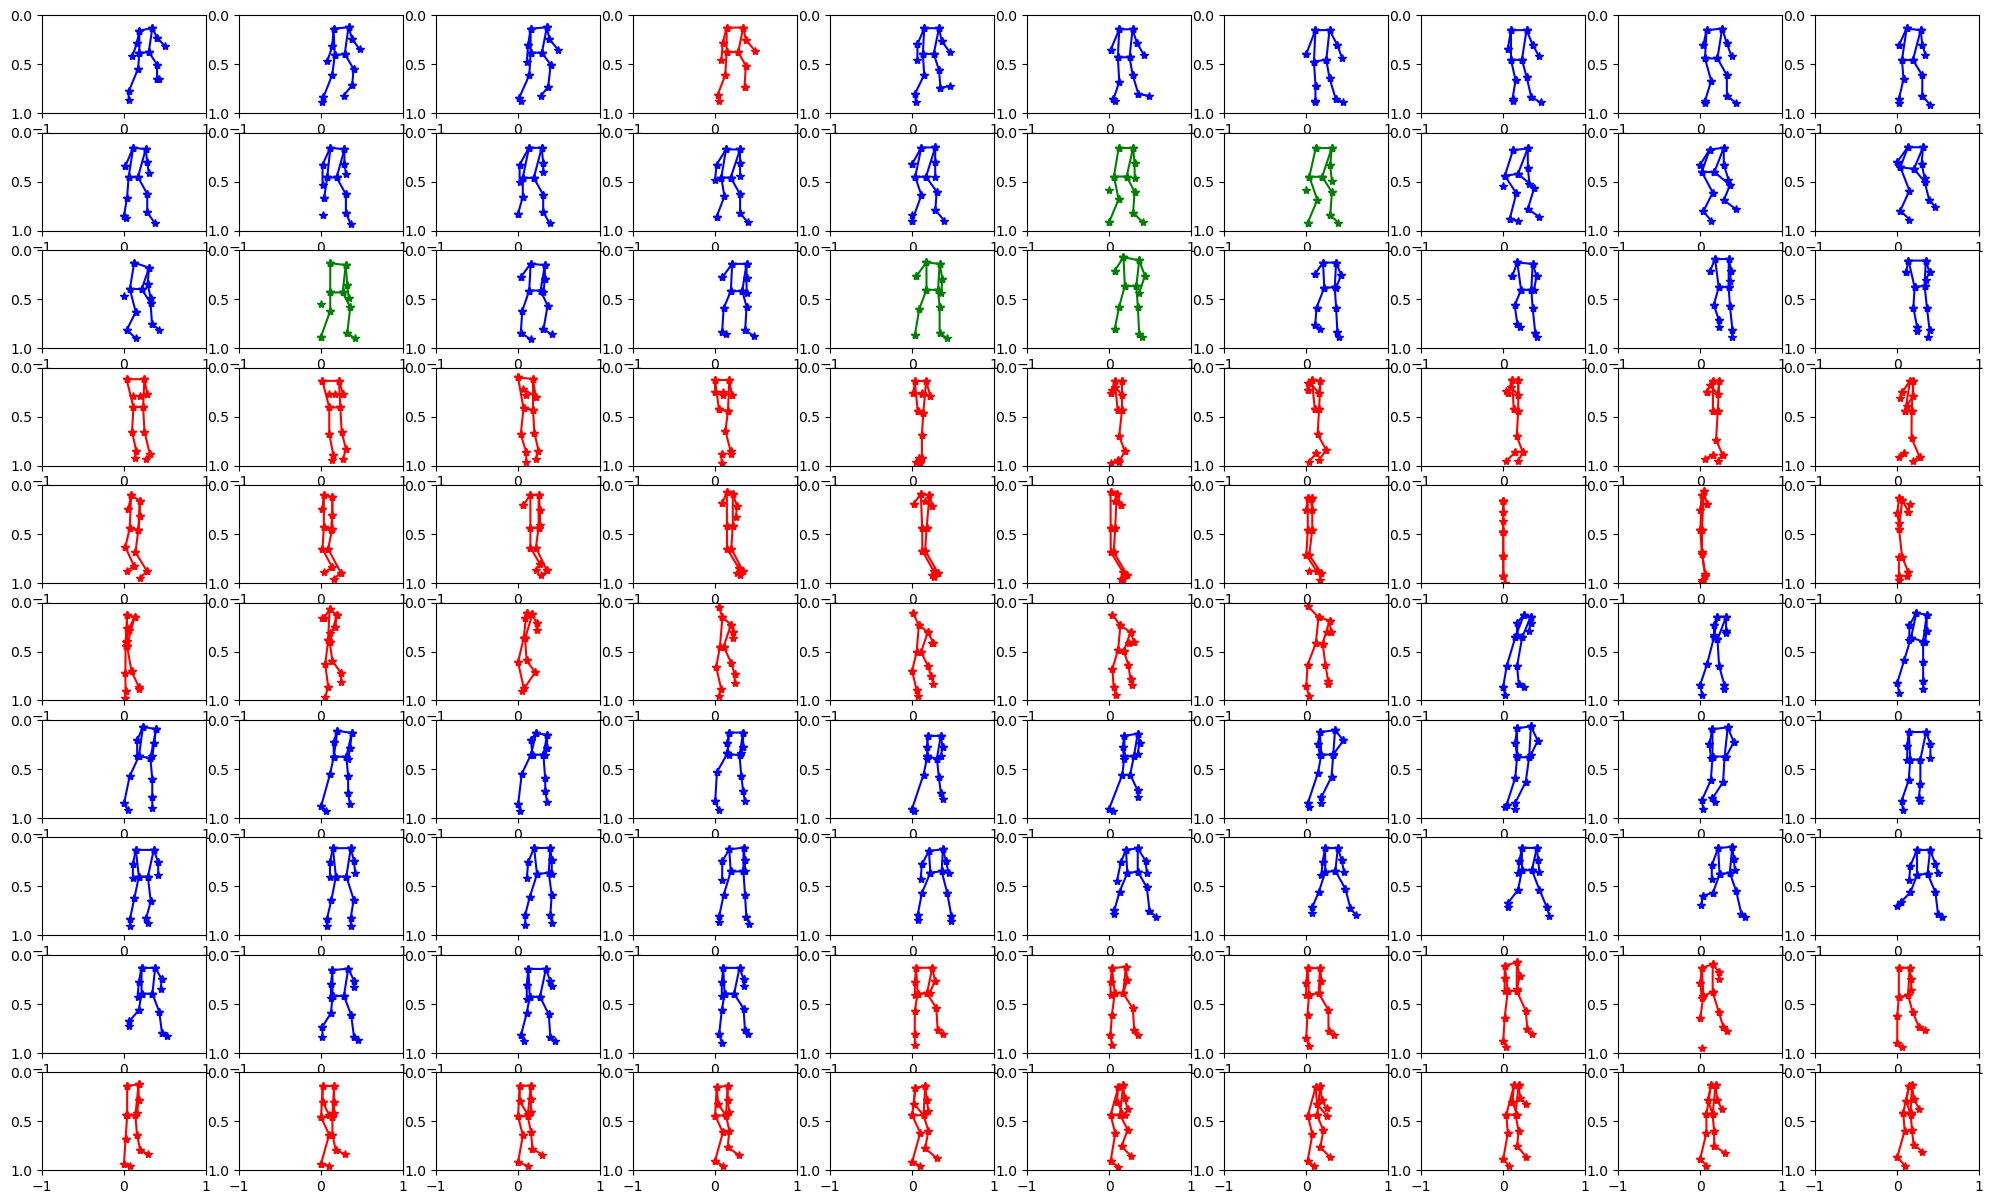

In [11]:
agg_clustering = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')

agg_clustering.fit(sequence) 

cluster_labels_agglomerative = agg_clustering.labels_

colors = {
    0: 'red', 1: 'blue', 2: 'green', 3: 'orange', 4: 'black', 5: 'brown', 6: 'yellow', 7: 'cyan', 8: 'magenta', 9: 'lime', 10: 'teal', 11: 'indigo', 
    12: 'violet', 13: 'gold', 
    14: 'silver', 15: 'pink', 16: 'maroon', 17: 'navy', 18: 'olive', 19: 'purple', 20: 'gray', 21: 'beige', 22: 'coral', 23: 'khaki', 24: 'lavender', 
    25: 'salmon', 26: 'skyblue', 27: 'turquoise', 28: 'white', 29: 'fuchsia'
}

plt.figure(figsize=(25,15))
for i in range(len(sequence)):
    plt.subplot(10, 10, i + 1)
    plot_single_pose(sequence[i], c=colors[cluster_labels_agglomerative[i]], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)



# Write your solution here (agglomerative clustering and cluster centers)


---
**Task 15 (easy): Agglomerative clustreing algorithm mean pose👩‍💻**
1. The `AgglomerativeClustering()`
 class does not have a method for directly extracting cluster centers. Calculate the mean pose within each cluster for $k = 3$  and plot it.
2. Change the distance metric (try `l1`
 and `cosine`
) and repeat the previous two tasks ([Task 14](#loading11) and [Task 15](#loading12).1). 


---

" print(cluster_labels_agglomerative)\nindexes_for_label_0 = [i for i in range(len(cluster_labels_agglomerative)) if cluster_labels_agglomerative[i] == 0]\n#print(len(indexes_for_label_0))\nlabel_0_poses = sequence[indexes_for_label_0]\n#mean_pose_label_0 = np.mean(label_0_poses)\n#print(mean_pose_label_0)\n#print(np.mean( np.array([ label_0_poses ]), axis=0 ))\nmean_pose_label_0 = np.mean(label_0_poses, axis=0)\nprint(mean_pose_label_0.shape)\n\n\n#plt.subplot(1, len(centroids_mean_shift), i+1)\nplt.title(f'Cluster center 0')\nplot_single_pose(mean_pose_label_0, c=colors[0], head=False)\nplt.ylim(1, 0)\nplt.xlim(-1, 1)\n "

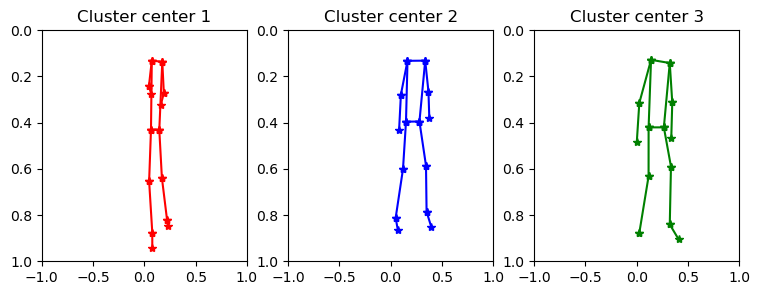

In [12]:
# Write your solution here
num_centroids = 3
# Set up subplots
fig, axes = plt.subplots(1, num_centroids, figsize=(num_centroids * 3, 3))

for i in range(3): 
    indexes_for_label = [j for j in range(len(cluster_labels_agglomerative)) if cluster_labels_agglomerative[j] == i]
    label_poses = sequence[indexes_for_label]
    mean_pose_label = np.mean(label_poses, axis=0)
    plt.subplot(1, 3, i+1)
    plt.title(f'Cluster center {i+1}')
    plot_single_pose(mean_pose_label, c=colors[i], head=False)
    plt.ylim(1, 0)
    plt.xlim(-1, 1)

""" print(cluster_labels_agglomerative)
indexes_for_label_0 = [i for i in range(len(cluster_labels_agglomerative)) if cluster_labels_agglomerative[i] == 0]
#print(len(indexes_for_label_0))
label_0_poses = sequence[indexes_for_label_0]
#mean_pose_label_0 = np.mean(label_0_poses)
#print(mean_pose_label_0)
#print(np.mean( np.array([ label_0_poses ]), axis=0 ))
mean_pose_label_0 = np.mean(label_0_poses, axis=0)
print(mean_pose_label_0.shape)


#plt.subplot(1, len(centroids_mean_shift), i+1)
plt.title(f'Cluster center 0')
plot_single_pose(mean_pose_label_0, c=colors[0], head=False)
plt.ylim(1, 0)
plt.xlim(-1, 1)
 """
#print(centroids_mean_shift[0])

#print(indexes_for_label_0)


---
**Task 16 (easy): Agglomerative clustreing algorithm mean pose💡📽️**
1. What differences do you observe?
2. Explain why these differences occur? 
3. Does a different distance metric result in more meaningful clusters, why/why not?


---

## Answers:
https://www.geeksforgeeks.org/machine-learning/agglomerative-clustering-with-different-metrics-in-scikit-learn/
Euclidean Distance: It measures the straight line distance between 2 points in space.

Cosine Similarity: It measures the angular cosine similarity between 2 vectors.

L1 sums the absolute differences between coordinates, while L2 (Euclidian) sums the squares of the differences and takes the square root. L1 is often more robust to outliers, while L2 is more sensitive to them because it squares the values

With cosine similarity, two vectors can be similar even if they are really big because their angular distance might be small. But if you fx compare the coordinates, then it will seem like the vectors are far apart/not similar. 


Using l1 metric makes the clusters larger, meaning more poses are in each cluster. These clusters look quite meaningful. 

Cosine makes two very large clusters and then one small cluster with only 2 poses. Seems like cosine maybe doesn't perform that well on this dataset - the two poses in the small cluster also look very different (one is the pose that looks like a straight line, and the other pose is one where we see the full body), so it doesn't really make sense that these are clustered together i think?

Euclidian also makes two very large clusters and then a small cluster of 5 poses. But I think the clusters look more meaningful using euclidian. 



## Comparison

---
**Task 17 (medium): Compare and reflect on the methods👩‍💻💡📽️**
1. Compare the clustered poses obtained with the different clustering methods (K-means, Mean-shift and Agglomerative clustering). What are the similarities and differences between the pose clusters across methods?
2. Why can clusters look similar across methods? 
3. What are the main reasons behind differences in the clusters?
4. The algorithms use different methods for determining the number of clusters. How do these differences impact the results for the pose data?


---

### Answer:

The consistency of the results produced by clustering algorithms, given the same data and parameters, can depend significantly on the algorithm being used. Clusters can look similar, but they can also vary a lot from method to method. 

In the K-Means clustering algorithm, the number of clusters (k) is a required input parameter and is not determined automatically by the algorithm. The user must specify the number of clusters they wish to use before running the algorithm. K-means reandomly selects K centers and assign all other data points to its' nearest center, and then it computes the new center for each cluster, and then iteratively reassign the data points to their new nearest center. K-Means clustering is sensitive to noise and outliers in the dataset. The objective of K-Means is to minimize the within-cluster sum of squares, and thus it is largely influenced by extreme values or outliers because squaring the distances amplifies the impact of large values. 

Clusters can look similar across methods if the data is very clearly divided into clusters originally, or if a lot of data points are very similar to each other. Then it is very likely that all methods will show somewhat the same clusters. 

The number of clusters can also differ across methods - fx agglomerative clustering results 3 clusters, while mean shift results 8 clusters (however this depends on the search window). 

K-means is highly sensitive to outliers because a single extreme pose can pull the entire cluster centroid toward it. Mean Shift is generally more robust because it ignores low-density "background" noise.

K-means requires us to make some prior assumptions about the data and the number of clusters, whereas the other methods iteratively find the most optimal amount of clusters given the settings (fx the bandwidth in mean shift, or the linkage type in agglomerative clustering)


